# Global Agri-Food Supply Chains: A Decadal Macro-Economic Archetype Analysis

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

In [120]:


# Load the dataset using your exact file name
file_name = 'Expanded Rows Agrofood.csv'
df = pd.read_csv(file_name)

# Let's inspect its shape and columns
print("✨ Dataset successfully loaded into Google Colab!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("-" * 50)

# Peek at the first few rows
df.head(3)

✨ Dataset successfully loaded into Google Colab!
Total Rows: 6965
Total Columns: 31
--------------------------------------------------


,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,Net Forest conversion,Food Household Consumption,Food Retail,On-farm Electricity Use,Food Packaging,Agrifood Systems Waste Disposal,Food Processing,Fertilizers Manufacturing,IPPU,Manure applied to Soils,Manure left on Pasture,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,0.0,79.0851,109.6446,14.2666,67.631366,691.7888,252.21419,11.9970,209.9778,260.1431,1590.5319,319.1763,0.0,0.0,NaN,9655167,2593947,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,0.0,80.4885,116.6789,11.4182,67.631366,710.8212,252.21419,12.8539,217.0388,268.6292,1657.2364,342.3079,0.0,0.0,NaN,10230490,2763167,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,0.0,80.7692,126.1721,9.2752,67.631366,743.6751,252.21419,13.4929,222.1156,264.7898,1653.5068,349.1224,0.0,0.0,NaN,10995568,2985663,6028494.0,6028939.0,2356.304229,-0.259583


In [121]:
# 1. Count the number of unique values in the Area column
unique_area_count = df['Area'].nunique()
unique_area_count

236

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965 entries, 0 to 6964
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             6965 non-null   object 
 1   Year                             6965 non-null   int64  
 2   Savanna fires                    6934 non-null   float64
 3   Forest fires                     6872 non-null   float64
 4   Crop Residues                    5576 non-null   float64
 5   Rice Cultivation                 6965 non-null   float64
 6   Drained organic soils (CO2)      6965 non-null   float64
 7   Pesticides Manufacturing         6965 non-null   float64
 8   Food Transport                   6965 non-null   float64
 9   Forestland                       6472 non-null   float64
 10  Net Forest conversion            6472 non-null   float64
 11  Food Household Consumption       6492 non-null   float64
 12  Food Retail         

In [123]:
# Filter the dataset to isolate only the years from 2010 to 2020
df_filtered = df[(df['Year'] >= 2010) & (df['Year'] <= 2020)].copy()

print(f"✅ Filter applied successfully!")
print(f"Total rows in your new modern dataset: {df_filtered.shape[0]}")

✅ Filter applied successfully!
Total rows in your new modern dataset: 2496


In [124]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2496 entries, 20 to 6964
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             2496 non-null   object 
 1   Year                             2496 non-null   int64  
 2   Savanna fires                    2485 non-null   float64
 3   Forest fires                     2463 non-null   float64
 4   Crop Residues                    2004 non-null   float64
 5   Rice Cultivation                 2496 non-null   float64
 6   Drained organic soils (CO2)      2496 non-null   float64
 7   Pesticides Manufacturing         2496 non-null   float64
 8   Food Transport                   2496 non-null   float64
 9   Forestland                       2320 non-null   float64
 10  Net Forest conversion            2320 non-null   float64
 11  Food Household Consumption       2342 non-null   float64
 12  Food Retail             

In [125]:
modern_year_counts = df_filtered['Year'].value_counts().sort_index()
modern_year_counts

,count
Year,
2010,227
2011,226
2012,227
2013,227
2014,227
2015,227
2016,227
2017,227
2018,227


In [126]:
# 1. Define the exact list of fire and forestry columns to drop
columns_to_drop = [
    'Savanna fires',
    'Forest fires',
    'Forestland',
    'Net Forest conversion',
    'Fires in humid tropical forests'
]

# 2. Drop them from our filtered 2010-2020 dataset
df_pruned = df_filtered.drop(columns=columns_to_drop, errors='ignore')

print("🧹 Fire and Forestry columns successfully dropped!")
print(f"Old column count: {df_filtered.shape[1]}")
print(f"New column count: {df_pruned.shape[1]} columns remaining.")
print("-" * 50)
print(df_pruned.shape)
# 3. List the remaining columns to verify our clean dataset
list(df_pruned.columns)

🧹 Fire and Forestry columns successfully dropped!
Old column count: 31
New column count: 26 columns remaining.
--------------------------------------------------
(2496, 26)


['Area',
 'Year',
 'Crop Residues',
 'Rice Cultivation',
 'Drained organic soils (CO2)',
 'Pesticides Manufacturing',
 'Food Transport',
 'Food Household Consumption',
 'Food Retail',
 'On-farm Electricity Use',
 'Food Packaging',
 'Agrifood Systems Waste Disposal',
 'Food Processing',
 'Fertilizers Manufacturing',
 'IPPU',
 'Manure applied to Soils',
 'Manure left on Pasture',
 'Manure Management',
 'Fires in organic soils',
 'On-farm energy use',
 'Rural population',
 'Urban population',
 'Total Population - Male',
 'Total Population - Female',
 'total_emission',
 'Average Temperature °C']

In [127]:
# Count missing values within our clean 2010-2020 decade
missing_counts = df_pruned.isnull().sum()
missing_counts

,0
Area,0
Year,0
Crop Residues,492
Rice Cultivation,0
Drained organic soils (CO2),0
Pesticides Manufacturing,0
Food Transport,0
Food Household Consumption,154
Food Retail,0
On-farm Electricity Use,0


In [128]:
missing_counts_columns= missing_counts[missing_counts>0]
missing_counts_columns

,0
Crop Residues,492
Food Household Consumption,154
IPPU,264
Manure applied to Soils,322
Manure Management,322
On-farm energy use,319


In [129]:
# 1. Create a filter that checks if ANY column in a row contains a missing value
any_missing_filter = df_pruned.isnull().any(axis=1)

# 2. Apply the filter to create a dedicated "missing data" DataFrame
df_missing_rows = df_pruned[any_missing_filter].copy()

print(f"📊 Created 'df_missing_rows' DataFrame successfully!")
print(f"Total rows with at least one missing value: {df_missing_rows.shape[0]}")
print("-" * 75)

# 3. View the first 10 rows, focusing on the columns we know have missing values
columns_to_show = ['Area', 'Year', 'Crop Residues', 'Food Household Consumption', 'IPPU', 'Manure applied to Soils', 'Manure Management','On-farm energy use']
df_missing_rows[columns_to_show].head(10)

📊 Created 'df_missing_rows' DataFrame successfully!
Total rows with at least one missing value: 788
---------------------------------------------------------------------------


,Area,Year,Crop Residues,Food Household Consumption,IPPU,Manure applied to Soils,Manure Management,On-farm energy use
20,Afghanistan,2010,413.6467,286.0954,192.3002,438.1226,849.3353,NaN
21,Afghanistan,2011,335.0379,522.6275,192.3717,449.4714,843.1709,NaN
22,Afghanistan,2012,445.5958,534.4065,266.4513,441.8546,836.9089,NaN
23,Afghanistan,2013,455.0727,833.2319,333.5334,432.0026,832.8961,NaN
24,Afghanistan,2014,473.4174,1094.1338,282.6155,437.6203,842.5037,NaN
25,Afghanistan,2015,403.3181,1570.3394,256.7030,423.5038,797.9007,NaN
26,Afghanistan,2016,387.6130,1649.8382,302.7560,421.9268,793.9377,NaN
27,Afghanistan,2017,344.6447,1431.5300,273.8355,422.4022,768.6802,NaN
28,Afghanistan,2018,291.7838,1392.5480,298.9150,427.5072,789.3364,NaN
29,Afghanistan,2019,395.2689,1520.2581,308.9680,387.9500,766.5012,NaN


In [130]:
# 1. Group the missing data by 'Area' and count the number of rows for each group
missing_by_area = df_missing_rows.groupby('Area').size()

# 2. Sort the results so the countries with the MOST missing rows are at the top
missing_by_area_sorted = missing_by_area.sort_values(ascending=False)

print("📊 Number of rows with missing data per Country/Area (2010-2020):")
print("-" * 65)
print(missing_by_area_sorted.head(10))


📊 Number of rows with missing data per Country/Area (2010-2020):
-----------------------------------------------------------------
Area
Afghanistan               11
American Samoa            11
Andorra                   11
Anguilla                  11
Aruba                     11
Bahrain                   11
Bermuda                   11
British Virgin Islands    11
Burkina Faso              11
Cameroon                  11
dtype: int64


In [131]:
# Force Pandas to display up to 100 rows on the screen without truncating
print(missing_by_area_sorted.shape)
with pd.option_context('display.max_rows', 100):
    display(missing_by_area_sorted)

(73,)


,0
Area,
Afghanistan,11
American Samoa,11
Andorra,11
Anguilla,11
Aruba,11
Bahrain,11
Bermuda,11
British Virgin Islands,11
Burkina Faso,11


In [132]:
# 1. Define your list of  countries to inspect
list_countries = [
    'China', 'China, Hong Kong SAR', 'United Arab Emirates', 'Saudi Arabia',
    'Singapore', 'Turkmenistan', 'Paraguay', 'Oman', 'Kuwait', 'Bahrain','Iraq'
]

print("🔎 DETAILED DIAGNOSTIC: Missing Columns for Key Countries (2010-2020)")
print("=" * 80)

# 2. Loop through each country and run a targeted missing value check
for country in list_countries:
    # Filter the modern 2010-2020 dataset for this specific country
    country_df = df_pruned[df_pruned['Area'] == country]

    # Safety Check: If the exact name isn't found, find closest matches
    #if country_df.empty:
        #matches = df_pruned[df_pruned['Area'].str.contains(country[:5], case=False, na=False)]['Area'].unique()
        #print(f"❓ Country name '{country}' not found exactly.")
        #print(f"   Did you mean one of these in your CSV? -> {list(matches)}")
        #print("-" * 80)
        #continue

    # Count missing values for this country's columns
    missing_cols = country_df.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0]

    # Print the findings
    if missing_cols.empty:
        print(f"✅ {country}: Fantastic! Has ZERO missing values in this window.")
    else:
        print(f"⚠️ {country}: Missing data in the following columns:")
        for col, count in missing_cols.items():
            print(f"   👉 '{col}': missing {count} years (out of 11)")

    print("-" * 80)

🔎 DETAILED DIAGNOSTIC: Missing Columns for Key Countries (2010-2020)
✅ China: Fantastic! Has ZERO missing values in this window.
--------------------------------------------------------------------------------
⚠️ China, Hong Kong SAR: Missing data in the following columns:
   👉 'Crop Residues': missing 11 years (out of 11)
   👉 'On-farm energy use': missing 11 years (out of 11)
--------------------------------------------------------------------------------
⚠️ United Arab Emirates: Missing data in the following columns:
   👉 'On-farm energy use': missing 11 years (out of 11)
--------------------------------------------------------------------------------
⚠️ Saudi Arabia: Missing data in the following columns:
   👉 'On-farm energy use': missing 11 years (out of 11)
--------------------------------------------------------------------------------
⚠️ Singapore: Missing data in the following columns:
   👉 'Crop Residues': missing 11 years (out of 11)
   👉 'On-farm energy use': missing 11 ye

In [133]:
# 1. Create a fresh copy of your dataset to apply the fixes safely
df_fixed = df_pruned.copy()

# 2. Define the exact list of important countries you want to protect
important_countries = [
    'China, Hong Kong SAR', 'United Arab Emirates', 'Saudi Arabia',
    'Singapore', 'Turkmenistan', 'Paraguay', 'Oman', 'Kuwait', 'Bahrain','Iraq'
]

# 3. For these countries, fill any missing values in our target columns with 0
columns_to_fill = ['Crop Residues', 'On-farm energy use']

for country in important_countries:
    for col in columns_to_fill:
        df_fixed.loc[df_fixed['Area'] == country, col] = df_fixed.loc[df_fixed['Area'] == country, col].fillna(0)

print("🎯 Strategic Imputation Complete!")


🎯 Strategic Imputation Complete!


In [134]:
#Checking to see if blanks are filled
df_fixed.loc[df_fixed['Area'] == 'United Arab Emirates', 'On-farm energy use']

,On-farm energy use
6518,0.0
6519,0.0
6520,0.0
6521,0.0
6522,0.0
6523,0.0
6524,0.0
6525,0.0
6526,0.0
6527,0.0


###Missing Values Re-check

In [135]:
new_missing_filter = df_fixed.isnull().any(axis=1)
# 2. Apply the filter to create a dedicated "missing data" DataFrame
df_missing_rows_new = df_fixed[new_missing_filter].copy()

print(f"📊 Created 'df_missing_rows' DataFrame successfully!")
print(f"Total rows with at least one missing value: {df_missing_rows_new.shape[0]}")
print("-" * 75)

# 3. View the first 10 rows, focusing on the columns we know have missing values
#columns_to_show = ['Area', 'Year', 'Crop Residues', 'Food Household Consumption', 'IPPU', 'Manure applied to Soils', 'Manure Management','On-farm energy use']
#df_missing_rows_new[columns_to_show].head(10)


# 1. Group the missing data by 'Area' and count the number of rows for each group
missing_by_area_new = df_missing_rows_new.groupby('Area').size()

# 2. Sort the results so the countries with the MOST missing rows are at the top
missing_by_area_sorted_new = missing_by_area_new.sort_values(ascending=False)

#print("📊 Number of rows with missing data per Country/Area (2010-2020):")
#print("-" * 65)
#print(missing_by_area_sorted_new.head(10))

print(missing_by_area_sorted_new.shape)
with pd.option_context('display.max_rows', 100):
    display(missing_by_area_sorted_new)

📊 Created 'df_missing_rows' DataFrame successfully!
Total rows with at least one missing value: 678
---------------------------------------------------------------------------
(63,)


,0
Area,
Afghanistan,11
American Samoa,11
Andorra,11
Anguilla,11
Aruba,11
Bermuda,11
British Virgin Islands,11
Burkina Faso,11
Cameroon,11


In [136]:
# 1. Identify the remaining countries that STILL have missing values
remaining_problems = df_fixed[df_fixed.isnull().any(axis=1)]['Area'].unique()

# 2. Filter them out using the ~ (NOT) operator
df_final_clean = df_fixed[~df_fixed['Area'].isin(remaining_problems)].copy()

print("🧹 FINAL CLEANING COMPLETE!")
print(f"Number of empty micro-regions dropped: {len(remaining_problems)}")
print("-" * 60)
print(f"📊 Final Clean Dataset Shape: {df_final_clean.shape}")
print(f"🌍 Total pristine countries remaining for analysis: {df_final_clean['Area'].nunique()}")

🧹 FINAL CLEANING COMPLETE!
Number of empty micro-regions dropped: 63
------------------------------------------------------------
📊 Final Clean Dataset Shape: (1813, 26)
🌍 Total pristine countries remaining for analysis: 166


In [137]:
final_check = df_final_clean.isnull().sum().sum()
print(f"🕵️‍♂️ Total missing values remaining in df_final_clean: {final_check}")

🕵️‍♂️ Total missing values remaining in df_final_clean: 0


In [138]:
# Find the exact names of the countries that were left out of the final clean dataset
#original_countries = set(df['Area'].unique())
#clean_countries = set(df_final_clean['Area'].unique())

#dropped_countries = original_countries - clean_countries

#print(f"Total countries excluded across the entire process: {len(dropped_countries)}")
#print("-" * 70)
#print("📋 Here is the complete list of excluded regions/islands:")
#print(sorted(list(dropped_countries)))

In [139]:
# 1. Find rows where the combination of 'Area' and 'Year' is duplicated
duplicates = df_final_clean[df_final_clean.duplicated()]

print("🔍 DUPLICATE CHECK REPORT:")
print("=" * 60)

if duplicates.empty:
    print("🎉 EXCELLENT NEWS! No duplicate country-year entries found.")
    print("Each country has exactly one clean record per year.")
else:
    print(f"⚠️ Warning: Found {len(duplicates)} rows with duplicate Area/Year combos!")
    print("-" * 60)
    # Display the duplicates sorted by Area and Year so they sit next to each other
    display(duplicates[['Area', 'Year']].sort_values(by=['Area', 'Year']))

🔍 DUPLICATE CHECK REPORT:
🎉 EXCELLENT NEWS! No duplicate country-year entries found.
Each country has exactly one clean record per year.


###FEATURE ENGINEERING

In [140]:
print(df_final_clean.columns)

Index(['Area', 'Year', 'Crop Residues', 'Rice Cultivation',
       'Drained organic soils (CO2)', 'Pesticides Manufacturing',
       'Food Transport', 'Food Household Consumption', 'Food Retail',
       'On-farm Electricity Use', 'Food Packaging',
       'Agrifood Systems Waste Disposal', 'Food Processing',
       'Fertilizers Manufacturing', 'IPPU', 'Manure applied to Soils',
       'Manure left on Pasture', 'Manure Management', 'Fires in organic soils',
       'On-farm energy use', 'Rural population', 'Urban population',
       'Total Population - Male', 'Total Population - Female',
       'total_emission', 'Average Temperature °C'],
      dtype='object')


In [141]:
#Checking the minimum values to ensure there are no negative values
# Corrected list matching exact casing from your DataFrame index
features_to_check = [
    'Crop Residues', 'Rice Cultivation', 'Drained organic soils (CO2)',
    'Fires in organic soils', 'Manure applied to Soils', 'Manure left on Pasture',
    'Manure Management', 'On-farm energy use', 'On-farm Electricity Use', # Fixed casing here
    'Food Transport', 'Food Processing', 'Food Packaging',
    'Food Retail', 'Food Household Consumption', 'Agrifood Systems Waste Disposal',
    'Pesticides Manufacturing', 'Fertilizers Manufacturing', 'IPPU'
]

# Print out the minimum values for each of these columns
print("🔍 Checking minimum values to ensure no negative data anomalies:")
print(df_final_clean[features_to_check].min())

🔍 Checking minimum values to ensure no negative data anomalies:
Crop Residues                      0.0000
Rice Cultivation                   0.0000
Drained organic soils (CO2)        0.0000
Fires in organic soils             0.0000
Manure applied to Soils            0.5558
Manure left on Pasture             2.2518
Manure Management                  0.9210
On-farm energy use                 0.0000
On-farm Electricity Use            0.0007
Food Transport                     4.1865
Food Processing                    0.0324
Food Packaging                     0.0020
Food Retail                        0.4275
Food Household Consumption         0.8110
Agrifood Systems Waste Disposal    3.8114
Pesticides Manufacturing           0.0000
Fertilizers Manufacturing          0.0084
IPPU                               0.0000
dtype: float64


In [142]:
df_final_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1813 entries, 51 to 6964
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             1813 non-null   object 
 1   Year                             1813 non-null   int64  
 2   Crop Residues                    1813 non-null   float64
 3   Rice Cultivation                 1813 non-null   float64
 4   Drained organic soils (CO2)      1813 non-null   float64
 5   Pesticides Manufacturing         1813 non-null   float64
 6   Food Transport                   1813 non-null   float64
 7   Food Household Consumption       1813 non-null   float64
 8   Food Retail                      1813 non-null   float64
 9   On-farm Electricity Use          1813 non-null   float64
 10  Food Packaging                   1813 non-null   float64
 11  Agrifood Systems Waste Disposal  1813 non-null   float64
 12  Food Processing         

In [143]:
# Check the maximum values to ensure no single feature has a corrupted massive value
df_final_clean[features_to_check].describe().loc[['75%', 'max']]

,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Fires in organic soils,Manure applied to Soils,Manure left on Pasture,Manure Management,On-farm energy use,On-farm Electricity Use,Food Transport,Food Processing,Food Packaging,Food Retail,Food Household Consumption,Agrifood Systems Waste Disposal,Pesticides Manufacturing,Fertilizers Manufacturing,IPPU
75%,506.3740,1269.2960,2370.1820,0.000,651.0682,2936.6909,1546.3985,1453.5104,582.7215,2008.3788,1942.597775,477.1756,2463.9279,2735.4877,5452.1497,211.0,2519.142474,1.244845e+04
max,33490.0741,152668.1134,241025.0696,569991.244,29865.2503,92630.7568,67787.8680,139388.9236,165676.2990,67945.7650,274253.512500,175741.3061,133784.0653,466288.2007,213289.7016,12154.0,170826.423300,1.861641e+06


In [144]:
# 1. Initialize our clean structural and demographic dataframe
df_sectors = df_final_clean[['Area', 'Year', 'Rural population', 'Urban population',
                              'Total Population - Male', 'Total Population - Female','total_emission', 'Average Temperature °C']].copy()

# 2. Group the precise column names into their verified supply chain sectors
farm_gate_cols = [
    'Crop Residues', 'Rice Cultivation', 'Drained organic soils (CO2)',
    'Fires in organic soils', 'Manure applied to Soils', 'Manure left on Pasture',
    'Manure Management', 'On-farm energy use', 'On-farm Electricity Use'
]

logistics_processing_cols = ['Food Transport', 'Food Processing', 'Food Packaging']

consumer_retail_cols = ['Food Retail', 'Food Household Consumption', 'Agrifood Systems Waste Disposal']

industries_cols = ['Pesticides Manufacturing', 'Fertilizers Manufacturing', 'IPPU']

# 3. Sum the kiloton emissions across the columns for each row
df_sectors['Farm_Gate_Emissions'] = df_final_clean[farm_gate_cols].sum(axis=1)
df_sectors['Logistics_Processing_Emissions'] = df_final_clean[logistics_processing_cols].sum(axis=1)
df_sectors['Consumer_Retail_Emissions'] = df_final_clean[consumer_retail_cols].sum(axis=1)
df_sectors['Industrial_Emissions'] = df_final_clean[industries_cols].sum(axis=1)

# 4. Confirm execution and inspect the resulting structure
print("🎯 Phase 2 Milestone: 4-Sector Supply Chain Aggregation Complete!")
print(f"New DataFrame dimensions: {df_sectors.shape}")
df_sectors.head()

🎯 Phase 2 Milestone: 4-Sector Supply Chain Aggregation Complete!
New DataFrame dimensions: (1813, 12)


,Area,Year,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C,Farm_Gate_Emissions,Logistics_Processing_Emissions,Consumer_Retail_Emissions,Industrial_Emissions
51,Albania,2010,1406665,1533860,1459102.0,1454297.0,3185.584797,1.078500,1651.605397,427.2777,849.2521,1488.3212
52,Albania,2011,1368297,1558362,1453895.0,1446759.0,3651.408297,1.070500,1701.851697,435.3398,816.4850,1642.3515
53,Albania,2012,1333585,1586454,1450370.0,1441822.0,3713.212497,1.354583,1671.360697,429.4685,839.6473,1708.9252
54,Albania,2013,1302236,1616742,1448110.0,1438905.0,3901.025997,1.397417,1695.117397,459.7121,908.2522,1798.6934
55,Albania,2014,1272790,1647985,1446732.0,1437370.0,3936.105597,1.290250,1747.488097,491.3627,921.3982,1736.7793


In [145]:
# Create the total population calculation on the fly to check its minimum value
calculated_pop = df_sectors['Rural population'] + df_sectors['Urban population']

print("🔍 Verifying population denominators:")
print(f"Minimum single-row population found: {calculated_pop.min() :,}")
print(f"Number of rows with a population of 0: {(calculated_pop == 0).sum()}")

🔍 Verifying population denominators:
Minimum single-row population found: 71,440
Number of rows with a population of 0: 0


In [146]:
# Check the overall summary statistics for your calculated population column
df_sectors['Total_Population'] = df_sectors['Rural population'] + df_sectors['Urban population']

print("📊 Inspecting the distribution of your population denominator:")
print(df_sectors['Total_Population'].describe().apply(lambda x: f"{x:,.2f}"))

📊 Inspecting the distribution of your population denominator:
count            1,813.00
mean        51,377,292.30
std        186,643,600.11
min             71,440.00
25%          3,209,404.00
50%          9,719,265.00
75%         30,762,701.00
max      1,456,565,698.00
Name: Total_Population, dtype: object


In [147]:
# 1. Create the unified total population denominator
df_sectors['Total_Population'] = df_sectors['Rural population'] + df_sectors['Urban population']

# List of our 4 freshly engineered sector emissions columns
sector_cols = [
    'Farm_Gate_Emissions', 'Logistics_Processing_Emissions',
    'Consumer_Retail_Emissions', 'Industrial_Emissions'
]

# 2. Convert Kilotons to Tons (multiply by 1000) and divide by population
for col in sector_cols:
    per_capita_name = col.replace('_Emissions', '_Per_Capita')
    df_sectors[per_capita_name] = (df_sectors[col] * 1000) / df_sectors['Total_Population']

# 3. Save a clean copy to represent the official completion of Phase 2
df_sectors_final = df_sectors.copy()

print("🏆 PHASE 2 MILESTONE ACHIEVED!")
print(f"Final Dataframe Dimensions: {df_sectors_final.shape}")
df_sectors_final.head()

🏆 PHASE 2 MILESTONE ACHIEVED!
Final Dataframe Dimensions: (1813, 17)


,Area,Year,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C,Farm_Gate_Emissions,Logistics_Processing_Emissions,Consumer_Retail_Emissions,Industrial_Emissions,Total_Population,Farm_Gate_Per_Capita,Logistics_Processing_Per_Capita,Consumer_Retail_Per_Capita,Industrial_Per_Capita
51,Albania,2010,1406665,1533860,1459102.0,1454297.0,3185.584797,1.078500,1651.605397,427.2777,849.2521,1488.3212,2940525,0.561670,0.145307,0.288810,0.506141
52,Albania,2011,1368297,1558362,1453895.0,1446759.0,3651.408297,1.070500,1701.851697,435.3398,816.4850,1642.3515,2926659,0.581500,0.148750,0.278982,0.561169
53,Albania,2012,1333585,1586454,1450370.0,1441822.0,3713.212497,1.354583,1671.360697,429.4685,839.6473,1708.9252,2920039,0.572376,0.147076,0.287547,0.585241
54,Albania,2013,1302236,1616742,1448110.0,1438905.0,3901.025997,1.397417,1695.117397,459.7121,908.2522,1798.6934,2918978,0.580723,0.157491,0.311154,0.616207
55,Albania,2014,1272790,1647985,1446732.0,1437370.0,3936.105597,1.290250,1747.488097,491.3627,921.3982,1736.7793,2920775,0.598296,0.168230,0.315464,0.594630


In [148]:
year_counts = df_sectors_final['Year'].value_counts().sort_index()
year_counts

,count
Year,
2010,164
2011,164
2012,165
2013,165
2014,165
2015,165
2016,165
2017,165
2018,165


In [149]:
area_count = df_sectors_final['Area'].nunique()
area_count

166

In [150]:
# 1. Get the raw value counts of rows for each country
area_counts = df_sectors_final['Area'].value_counts()

# 2. Filter for countries where the row count is LESS than 11
missing_years_countries = area_counts[area_counts < 11]

print(f"🔍 Found {len(missing_years_countries)} countries with incomplete data records:\n")
print(missing_years_countries)

🔍 Found 3 countries with incomplete data records:

Area
South Sudan       9
Sudan             9
Sudan (former)    2
Name: count, dtype: int64


In [151]:
# Optional: Filter out the legacy historical entity to keep only modern countries
df_sectors_final = df_sectors_final[df_sectors_final['Area'] != 'Sudan (former)']

In [152]:
df_sectors_final.shape

(1811, 17)

In [153]:
# PHASE 2: STEP 1 - COLLAPSE THE TIMELINE
columns_to_average = [
    'Total_Population',
    'Farm_Gate_Emissions',
    'Logistics_Processing_Emissions',
    'Consumer_Retail_Emissions',
    'Industrial_Emissions'
]

# Collapse into 11-year means per country
df_collapsed = df_sectors_final.groupby('Area')[columns_to_average].mean().reset_index()

# Defensive Check: Drop any country that has zero total emissions across all 4 sectors
total_emissions_sectors_sum = df_collapsed[['Farm_Gate_Emissions', 'Logistics_Processing_Emissions', 'Consumer_Retail_Emissions', 'Industrial_Emissions']].sum(axis=1)
df_collapsed = df_collapsed[total_emissions_sectors_sum > 0].reset_index(drop=True)

print("📊")
print(f"Final Shape for Modeling: {df_collapsed.shape}")
df_collapsed.head()

📊
Final Shape for Modeling: (165, 6)


,Area,Total_Population,Farm_Gate_Emissions,Logistics_Processing_Emissions,Consumer_Retail_Emissions,Industrial_Emissions
0,Albania,2.929244e+06,1689.962670,433.713936,960.496127,1689.110681
1,Algeria,3.979736e+07,5427.232727,7437.251800,28771.425291,16962.526318
2,Angola,2.794989e+07,5867.547502,1127.006058,3865.073182,2082.293183
3,Antigua and Barbuda,9.990891e+04,282.851931,444.572233,86.802182,1826.004417
4,Argentina,4.339420e+07,52313.795845,15940.878273,23484.973727,19408.524600


In [154]:
#COMPOSITIONAL FEATURE ENGINEERING (SECTOR SHARE PERCENTAGES)

# 1. Calculate the total food system emission footprint for each country
emission_sectors = ['Farm_Gate_Emissions', 'Logistics_Processing_Emissions', 'Consumer_Retail_Emissions', 'Industrial_Emissions']
df_collapsed['Total_Food_System_Emissions'] = df_collapsed[emission_sectors].sum(axis=1)

# 2. Compute the 4 Sector Share Percentages
df_collapsed['Farm_Gate_Share'] = (df_collapsed['Farm_Gate_Emissions'] / df_collapsed['Total_Food_System_Emissions']) * 100
df_collapsed['Logistics_Processing_Share'] = (df_collapsed['Logistics_Processing_Emissions'] / df_collapsed['Total_Food_System_Emissions']) * 100
df_collapsed['Consumer_Retail_Share'] = (df_collapsed['Consumer_Retail_Emissions'] / df_collapsed['Total_Food_System_Emissions']) * 100
df_collapsed['Industrial_Share'] = (df_collapsed['Industrial_Emissions'] / df_collapsed['Total_Food_System_Emissions']) * 100

print("🎯 Step 2 Complete! Sector percentages engineered successfully.")
print(f"Dataframe columns available now: {df_collapsed.columns.tolist()}")
df_collapsed[['Area', 'Farm_Gate_Share', 'Logistics_Processing_Share', 'Consumer_Retail_Share', 'Industrial_Share']].head()

🎯 Step 2 Complete! Sector percentages engineered successfully.
Dataframe columns available now: ['Area', 'Total_Population', 'Farm_Gate_Emissions', 'Logistics_Processing_Emissions', 'Consumer_Retail_Emissions', 'Industrial_Emissions', 'Total_Food_System_Emissions', 'Farm_Gate_Share', 'Logistics_Processing_Share', 'Consumer_Retail_Share', 'Industrial_Share']


,Area,Farm_Gate_Share,Logistics_Processing_Share,Consumer_Retail_Share,Industrial_Share
0,Albania,35.404616,9.086281,20.122336,35.386767
1,Algeria,9.261736,12.691895,49.099306,28.947063
2,Angola,45.337535,8.708183,29.864759,16.089523
3,Antigua and Barbuda,10.713152,16.838385,3.287674,69.160789
4,Argentina,47.066717,14.342007,21.129429,17.461848


In [155]:
df_collapsed.head()

,Area,Total_Population,Farm_Gate_Emissions,Logistics_Processing_Emissions,Consumer_Retail_Emissions,Industrial_Emissions,Total_Food_System_Emissions,Farm_Gate_Share,Logistics_Processing_Share,Consumer_Retail_Share,Industrial_Share
0,Albania,2.929244e+06,1689.962670,433.713936,960.496127,1689.110681,4773.283415,35.404616,9.086281,20.122336,35.386767
1,Algeria,3.979736e+07,5427.232727,7437.251800,28771.425291,16962.526318,58598.436136,9.261736,12.691895,49.099306,28.947063
2,Angola,2.794989e+07,5867.547502,1127.006058,3865.073182,2082.293183,12941.919925,45.337535,8.708183,29.864759,16.089523
3,Antigua and Barbuda,9.990891e+04,282.851931,444.572233,86.802182,1826.004417,2640.230763,10.713152,16.838385,3.287674,69.160789
4,Argentina,4.339420e+07,52313.795845,15940.878273,23484.973727,19408.524600,111148.172445,47.066717,14.342007,21.129429,17.461848


In [156]:
# Round the engineered sector share percentages to 2 decimal places
share_cols = ['Farm_Gate_Share', 'Logistics_Processing_Share', 'Consumer_Retail_Share', 'Industrial_Share']
df_collapsed[share_cols] = df_collapsed[share_cols].round(2)

# Verify the clean, reader-friendly output
df_collapsed[['Area'] + share_cols].head()

,Area,Farm_Gate_Share,Logistics_Processing_Share,Consumer_Retail_Share,Industrial_Share
0,Albania,35.40,9.09,20.12,35.39
1,Algeria,9.26,12.69,49.10,28.95
2,Angola,45.34,8.71,29.86,16.09
3,Antigua and Barbuda,10.71,16.84,3.29,69.16
4,Argentina,47.07,14.34,21.13,17.46


In [157]:
df_collapsed.head()

,Area,Total_Population,Farm_Gate_Emissions,Logistics_Processing_Emissions,Consumer_Retail_Emissions,Industrial_Emissions,Total_Food_System_Emissions,Farm_Gate_Share,Logistics_Processing_Share,Consumer_Retail_Share,Industrial_Share
0,Albania,2.929244e+06,1689.962670,433.713936,960.496127,1689.110681,4773.283415,35.40,9.09,20.12,35.39
1,Algeria,3.979736e+07,5427.232727,7437.251800,28771.425291,16962.526318,58598.436136,9.26,12.69,49.10,28.95
2,Angola,2.794989e+07,5867.547502,1127.006058,3865.073182,2082.293183,12941.919925,45.34,8.71,29.86,16.09
3,Antigua and Barbuda,9.990891e+04,282.851931,444.572233,86.802182,1826.004417,2640.230763,10.71,16.84,3.29,69.16
4,Argentina,4.339420e+07,52313.795845,15940.878273,23484.973727,19408.524600,111148.172445,47.07,14.34,21.13,17.46


In [158]:
df_collapsed.describe()

,Total_Population,Farm_Gate_Emissions,Logistics_Processing_Emissions,Consumer_Retail_Emissions,Industrial_Emissions,Total_Food_System_Emissions,Farm_Gate_Share,Logistics_Processing_Share,Consumer_Retail_Share,Industrial_Share
count,1.650000e+02,165.000000,165.000000,165.000000,1.650000e+02,1.650000e+02,165.000000,165.000000,165.000000,165.000000
mean,5.132822e+07,27285.435272,11874.968470,21157.411619,4.043492e+04,1.007527e+05,33.221515,10.016727,21.083818,35.678848
std,1.869949e+08,81616.695164,50693.622800,78894.721585,1.934336e+05,3.895873e+05,22.121544,5.615069,13.378176,22.957957
min,7.318627e+04,40.521927,139.614682,7.764745,2.650959e+02,1.327361e+03,0.380000,1.180000,0.170000,2.140000
25%,3.432979e+06,1629.669286,431.799176,1020.897627,1.826004e+03,6.595086e+03,15.970000,5.210000,10.170000,17.380000
50%,9.760993e+06,5135.836479,1127.006058,3296.690664,3.998112e+03,1.677885e+04,27.990000,9.290000,19.520000,31.620000
75%,3.095239e+07,18672.168511,4042.638706,10606.196009,1.546731e+04,4.285764e+04,46.730000,13.370000,29.940000,50.920000
max,1.426344e+09,557461.626718,444991.290082,684834.159991,1.717966e+06,3.381870e+06,89.880000,32.560000,78.340000,92.830000


###EDA

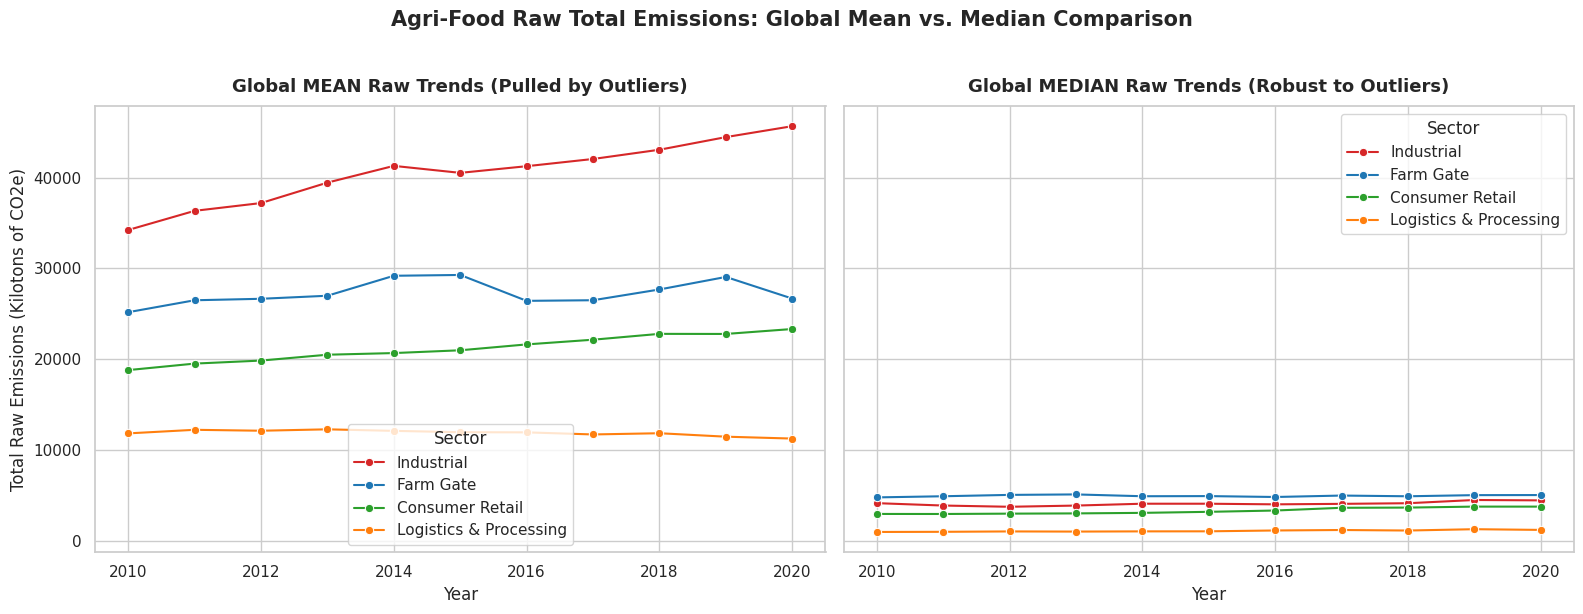

In [159]:

# 1. Handle potential variation in the Consumer Retail raw column name
retail_raw_col = 'Consumer_Retail_Emissions' if 'Consumer_Retail_Emissions' in df_sectors_final.columns else 'Consumer_Retail'

# Map columns to clean display names
raw_sectors = {
    'Industrial_Emissions': 'Industrial',
    'Farm_Gate_Emissions': 'Farm Gate',
    retail_raw_col: 'Consumer Retail',
    'Logistics_Processing_Emissions': 'Logistics & Processing'
}

# 2. Aggregate the data globally by Year
# Calculate the Mean across all records per year
df_raw_mean = df_sectors_final.groupby('Year')[list(raw_sectors.keys())].mean().reset_index()
# Calculate the Median across all records per year
df_raw_median = df_sectors_final.groupby('Year')[list(raw_sectors.keys())].median().reset_index()

# 3. Reshape (Melt) the dataframes so Seaborn can line-plot them cleanly
df_mean_melt = df_raw_mean.melt(id_vars='Year', value_vars=list(raw_sectors.keys()), var_name='Sector', value_name='Emissions')
df_mean_melt['Sector'] = df_mean_melt['Sector'].map(raw_sectors)

df_median_melt = df_raw_median.melt(id_vars='Year', value_vars=list(raw_sectors.keys()), var_name='Sector', value_name='Emissions')
df_median_melt['Sector'] = df_median_melt['Sector'].map(raw_sectors)

# 4. Create the side-by-side comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.set_theme(style="whitegrid")

# Custom color palette matching your original per-capita chart
custom_colors = {'Industrial': '#d62728', 'Farm Gate': '#1f77b4', 'Consumer Retail': '#2ca02c', 'Logistics & Processing': '#ff7f0e'}

# Left Graph: Mean Trends
sns.lineplot(data=df_mean_melt, x='Year', y='Emissions', hue='Sector', marker='o', ax=axes[0], palette=custom_colors)
axes[0].set_title('Global MEAN Raw Trends (Pulled by Outliers)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Total Raw Emissions (Kilotons of CO2e)', fontsize=12)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].tick_label_transform = None # Ensure year ticks look clean

# Right Graph: Median Trends
sns.lineplot(data=df_median_melt, x='Year', y='Emissions', hue='Sector', marker='o', ax=axes[1], palette=custom_colors)
axes[1].set_title('Global MEDIAN Raw Trends (Robust to Outliers)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Year', fontsize=12)

# Final formatting touches
plt.suptitle('Agri-Food Raw Total Emissions: Global Mean vs. Median Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

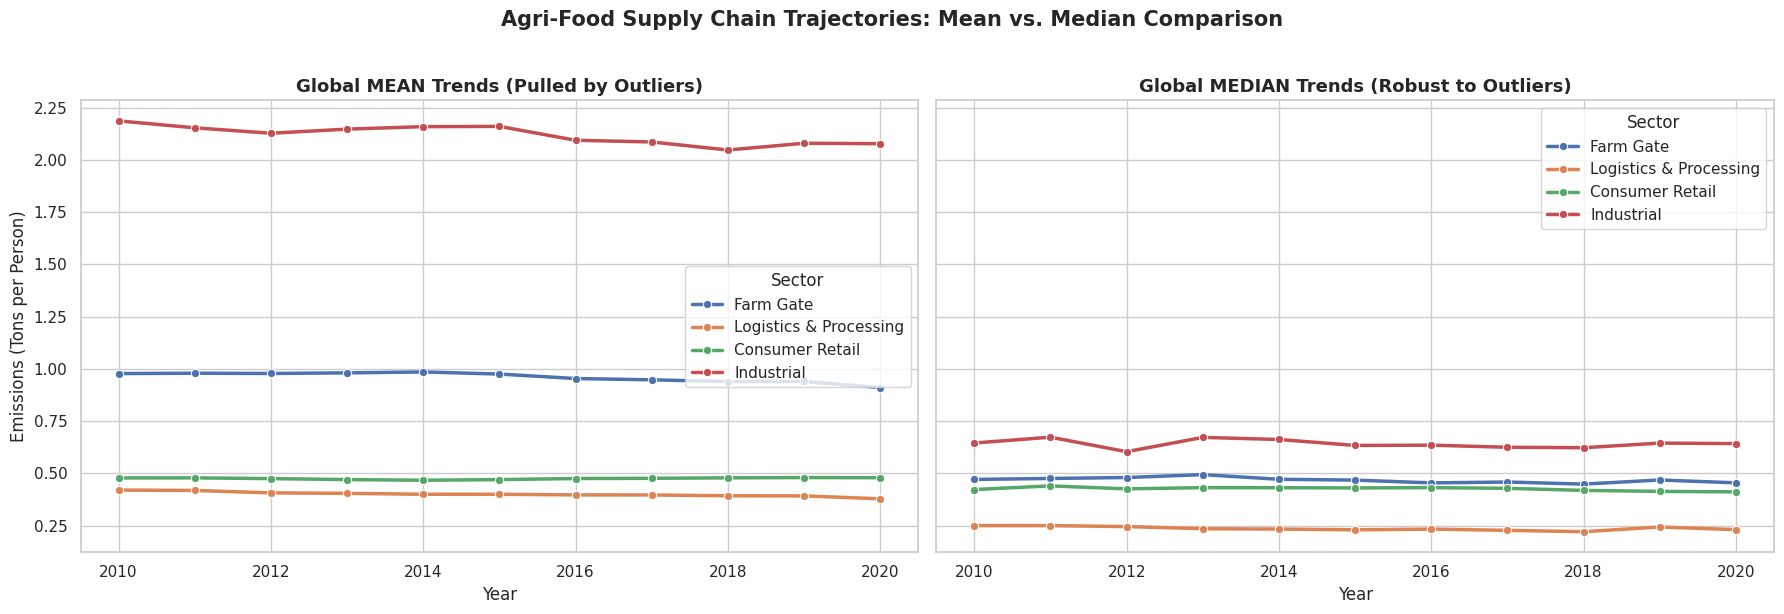

In [160]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# 1. Define your core sector metrics
target_cols = [
    'Farm_Gate_Per_Capita', 'Logistics_Processing_Per_Capita',
    'Consumer_Retail_Emissions_Per_Capita' if 'Consumer_Retail_Emissions_Per_Capita' in df_sectors_final.columns else 'Consumer_Retail_Per_Capita',
    'Industrial_Per_Capita'
]
display_names = ['Farm Gate', 'Logistics & Processing', 'Consumer Retail', 'Industrial']

# 📉 CHART 1: The Global Mean (Influenced by Outliers)
df_mean = df_sectors_final.groupby('Year')[target_cols].mean().reset_index()
df_mean.columns = ['Year'] + display_names
df_mean_melted = df_mean.melt(id_vars='Year', var_name='Sector', value_name='Tons Per Capita')

sns.lineplot(ax=axes[0], data=df_mean_melted, x='Year', y='Tons Per Capita', hue='Sector', marker='o', linewidth=2.5)
axes[0].set_title('Global MEAN Trends (Pulled by Outliers)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Emissions (Tons per Person)')

# 📉 CHART 2: The Global Median (The Typical Country Experience)
df_median = df_sectors_final.groupby('Year')[target_cols].median().reset_index()
df_median.columns = ['Year'] + display_names
df_median_melted = df_median.melt(id_vars='Year', var_name='Sector', value_name='Tons Per Capita')

sns.lineplot(ax=axes[1], data=df_median_melted, x='Year', y='Tons Per Capita', hue='Sector', marker='o', linewidth=2.5)
axes[1].set_title('Global MEDIAN Trends (Robust to Outliers)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('') # Hidden since sharey=True

plt.suptitle('Agri-Food Supply Chain Trajectories: Mean vs. Median Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [161]:
#  DESCRIPTIVE STATISTICAL ANALYSIS
share_cols = ['Farm_Gate_Share', 'Logistics_Processing_Share', 'Consumer_Retail_Share', 'Industrial_Share']

# Generate descriptive statistics and transpose for better readability
df_collapsed[share_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Farm_Gate_Share,165.0,33.22,22.12,0.38,15.97,27.99,46.73,89.88
Logistics_Processing_Share,165.0,10.02,5.62,1.18,5.21,9.29,13.37,32.56
Consumer_Retail_Share,165.0,21.08,13.38,0.17,10.17,19.52,29.94,78.34
Industrial_Share,165.0,35.68,22.96,2.14,17.38,31.62,50.92,92.83


/tmp/ipykernel_857/1846788771.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Farm Gate', 'Logistics', 'Consumer/Retail', 'Industrial'], rotation=15)


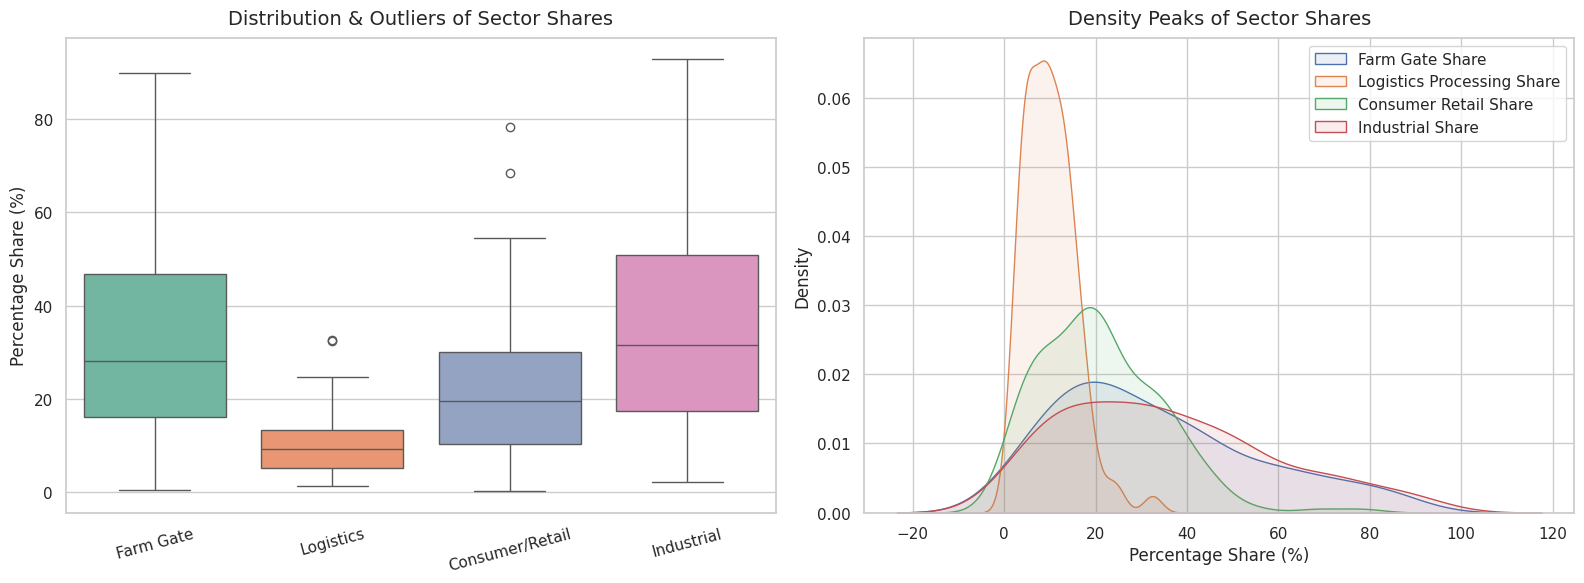

In [162]:

# Set up the plotting environment
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define our 4 sector share columns
share_cols = ['Farm_Gate_Share', 'Logistics_Processing_Share', 'Consumer_Retail_Share', 'Industrial_Share']

# Chart 1: Boxplot to see spreads, medians, and outliers
sns.boxplot(data=df_collapsed[share_cols], ax=axes[0], palette="Set2")
axes[0].set_title("Distribution & Outliers of Sector Shares", fontsize=14, pad=10)
axes[0].set_ylabel("Percentage Share (%)")
axes[0].set_xticklabels(['Farm Gate', 'Logistics', 'Consumer/Retail', 'Industrial'], rotation=15)

# Chart 2: KDE Plot to see the "peaks" (potential natural clusters)
for col in share_cols:
    sns.kdeplot(data=df_collapsed[col], label=col.replace('_', ' '), ax=axes[1], fill=True, alpha=0.1)
axes[1].set_title("Density Peaks of Sector Shares", fontsize=14, pad=10)
axes[1].set_xlabel("Percentage Share (%)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

We drop the Logistics share column to avoid the constant-sum constraint (multicollinearity)."

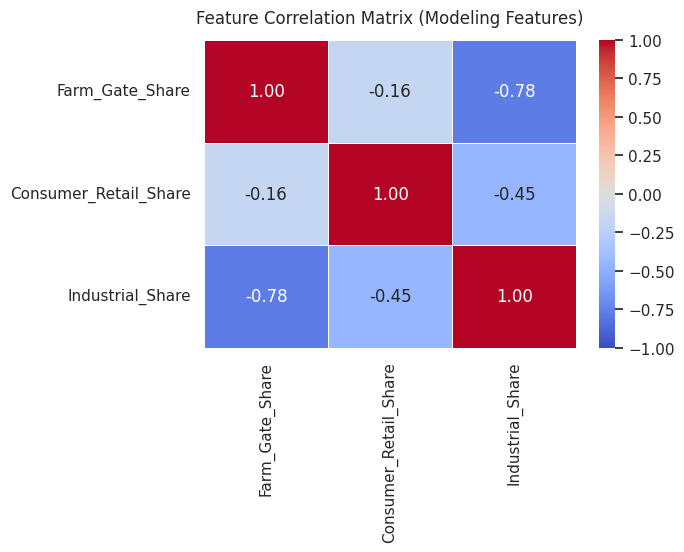

In [163]:
# EDA STEP - CORRELATION HEATMAP
plt.figure(figsize=(6, 4))

# Compute correlation matrix for the 3 columns we are feeding into K-Means
corr_matrix = df_collapsed[['Farm_Gate_Share', 'Consumer_Retail_Share', 'Industrial_Share']].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Modeling Features)', fontsize=12, pad=12)
plt.show()

In [164]:
#  FINAL EDA CELL: NULL & INFINITY AUDIT
modeling_features = ['Farm_Gate_Share', 'Consumer_Retail_Share', 'Industrial_Share']

print("🔍 Checking feature matrix for K-Means compatibility...")
print("-" * 50)

# Count null values
null_counts = df_collapsed[modeling_features].isnull().sum()
print("1. Null Values (NaN) per column:")
print(null_counts)
print("-" * 50)

# Count infinity values
inf_counts = np.isinf(df_collapsed[modeling_features]).sum()
print("2. Infinity Values (inf) per column:")
print(inf_counts)
print("-" * 50)

if null_counts.sum() == 0 and inf_counts.sum() == 0:
    print("✅ GREEN LIGHT! No NaNs or Infs found. The data is 100% ready for K-Means!")
else:
    print("⚠️ WARNING: Clean up required before modeling.")

🔍 Checking feature matrix for K-Means compatibility...
--------------------------------------------------
1. Null Values (NaN) per column:
Farm_Gate_Share          0
Consumer_Retail_Share    0
Industrial_Share         0
dtype: int64
--------------------------------------------------
2. Infinity Values (inf) per column:
Farm_Gate_Share          0
Consumer_Retail_Share    0
Industrial_Share         0
dtype: int64
--------------------------------------------------
✅ GREEN LIGHT! No NaNs or Infs found. The data is 100% ready for K-Means!


##K-means model

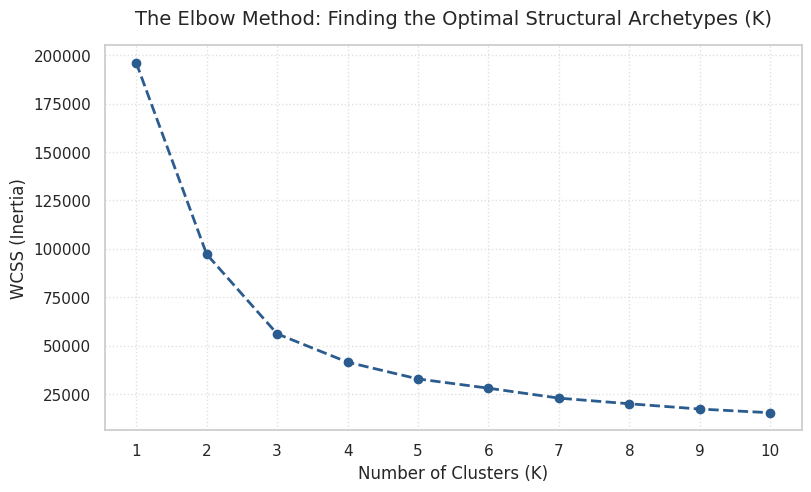

In [165]:

# 1. Isolate our final 3-column feature matrix
modeling_features = ['Farm_Gate_Share', 'Consumer_Retail_Share', 'Industrial_Share']
X = df_collapsed[modeling_features]

# 2. Compute WCSS for K values from 1 to 10
wcss = []
for k in range(1, 11):
    # k-means++ ensures smart initialization; random_state ensures reproducibility
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 3. Plot the final Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='#2b5c8f', linewidth=2)
plt.title('The Elbow Method: Finding the Optimal Structural Archetypes (K)', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [166]:
# 1. Initialize and fit K-Means with K=4
kmeans_final = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_final.fit(X)

# 2. Assign the cluster labels back to your complete 4-column dataframe
df_collapsed['Cluster_Labels'] = kmeans_final.labels_

# 3. Define the full list of 4 share columns for profiling
all_share_cols = ['Farm_Gate_Share', 'Industrial_Share', 'Consumer_Retail_Share', 'Logistics_Processing_Share']

# 4. Calculate the average profile for each cluster and round to 2 decimals
cluster_profiles = df_collapsed.groupby('Cluster_Labels')[all_share_cols].mean().round(2)

# Display the results!
print("🎯 CLUSTER PROFILES (Average Percentages per Archetype):")
print("-" * 70)
print(cluster_profiles)

🎯 CLUSTER PROFILES (Average Percentages per Archetype):
----------------------------------------------------------------------
                Farm_Gate_Share  Industrial_Share  Consumer_Retail_Share  \
Cluster_Labels                                                             
0                          8.90             75.65                   8.33   
1                         32.91             21.65                  34.77   
2                         67.97             11.62                  14.41   
3                         22.88             44.59                  19.17   

                Logistics_Processing_Share  
Cluster_Labels                              
0                                     7.13  
1                                    10.67  
2                                     6.00  
3                                    13.36  


In [167]:
df_collapsed.head()

,Area,Total_Population,Farm_Gate_Emissions,Logistics_Processing_Emissions,Consumer_Retail_Emissions,Industrial_Emissions,Total_Food_System_Emissions,Farm_Gate_Share,Logistics_Processing_Share,Consumer_Retail_Share,Industrial_Share,Cluster_Labels
0,Albania,2.929244e+06,1689.962670,433.713936,960.496127,1689.110681,4773.283415,35.40,9.09,20.12,35.39,3
1,Algeria,3.979736e+07,5427.232727,7437.251800,28771.425291,16962.526318,58598.436136,9.26,12.69,49.10,28.95,1
2,Angola,2.794989e+07,5867.547502,1127.006058,3865.073182,2082.293183,12941.919925,45.34,8.71,29.86,16.09,1
3,Antigua and Barbuda,9.990891e+04,282.851931,444.572233,86.802182,1826.004417,2640.230763,10.71,16.84,3.29,69.16,0
4,Argentina,4.339420e+07,52313.795845,15940.878273,23484.973727,19408.524600,111148.172445,47.07,14.34,21.13,17.46,1


In [168]:
df_collapsed.shape

(165, 12)

In [169]:
#  EXPLORE COUNTRIES IN EACH CLUSTER
# Set pandas option to show all columns clearly in the printout
import pandas as pd
pd.set_option('display.max_columns', None)

print("🌍 TOP 10 COUNTRIES PER STRUCTURAL ARCHETYPE (Sorted by Population):\n")
print("=" * 80)

# Loop through each of our 4 clusters (0 to 3)
for cluster_id in sorted(df_collapsed['Cluster_Labels'].unique()):
    print(f"\n🚀 ARCHETYPE {cluster_id} ")
    print("-" * 50)

    # 1. Filter the dataframe for the current cluster
    cluster_df = df_collapsed[df_collapsed['Cluster_Labels'] == cluster_id]

    # 2. Grab key identifying columns to display
    display_cols = ['Area', 'Total_Population', 'Farm_Gate_Share', 'Industrial_Share', 'Consumer_Retail_Share', 'Logistics_Processing_Share']

    # 3. Sort by population descending and grab the top 10 rows
    top_countries = cluster_df[display_cols].sort_values(by='Total_Population', ascending=False).head(10)

    # Print a clean text table
    print(top_countries.to_string(index=False))
    print("=" * 80)

🌍 TOP 10 COUNTRIES PER STRUCTURAL ARCHETYPE (Sorted by Population):


🚀 ARCHETYPE 0 
--------------------------------------------------
                            Area  Total_Population  Farm_Gate_Share  Industrial_Share  Consumer_Retail_Share  Logistics_Processing_Share
                    Saudi Arabia      3.133154e+07             3.98             65.36                  20.49                       10.17
Bolivia (Plurinational State of)      1.072743e+07            13.09             74.22                   8.12                        4.56
                        Portugal      1.043111e+07            11.03             66.64                  15.08                        7.26
                         Austria      8.638622e+06            12.00             69.61                   9.37                        9.02
                       Singapore      5.526548e+06             3.74             72.01                  19.04                        5.21
                            Oman      4.15

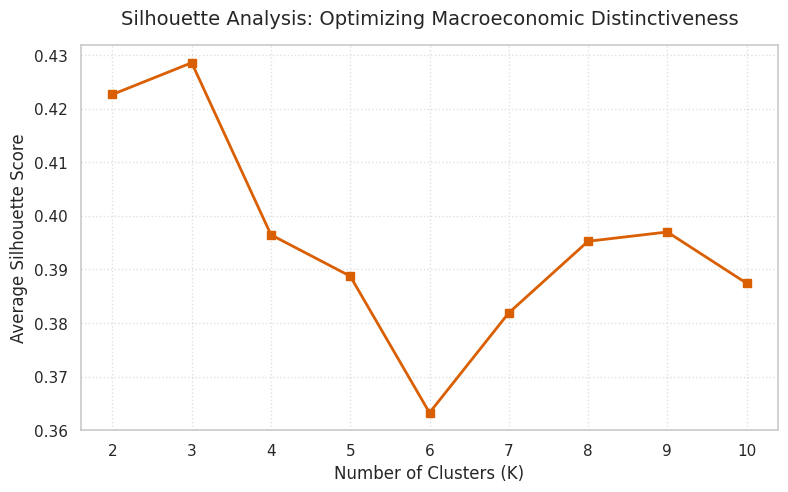

In [170]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_values = range(2, 11)  # Silhouette score requires at least 2 clusters to compare boundaries

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    # Calculate the average silhouette score for the entire dataset at this K
    score = silhouette_score(X, cluster_labels)
    sil_scores.append(score)

# Plotting the Silhouette Scores
plt.figure(figsize=(9, 5))
plt.plot(k_values, sil_scores, marker='s', linestyle='-', color='#d95f02', linewidth=2)
plt.title('Silhouette Analysis: Optimizing Macroeconomic Distinctiveness', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

📊 1. CHECKING CLUSTER SIZE BALANCE:
----------------------------------------
🚀 Archetype 0: 26 countries (15.8%)
🚀 Archetype 1: 49 countries (29.7%)
🚀 Archetype 2: 35 countries (21.2%)
🚀 Archetype 3: 55 countries (33.3%)

🔮 2. GENERATING 2D PCA SCATTER PLOT...
----------------------------------------


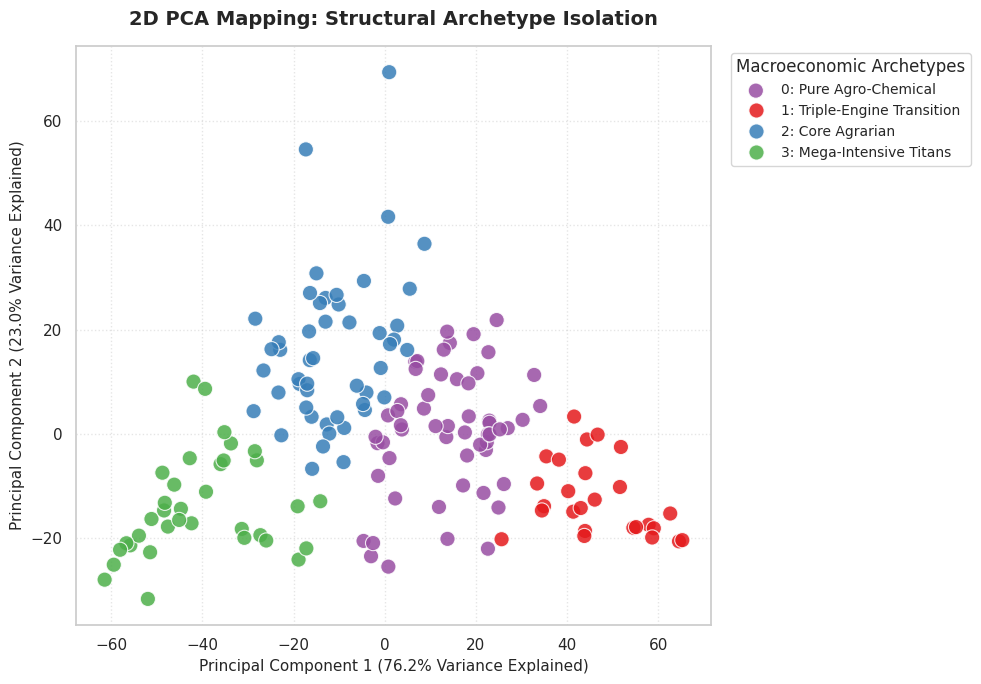

💡 Success! The 2D plot captures 99.2% of the total multidimensional variance.


In [171]:

from sklearn.decomposition import PCA

print("📊 1. CHECKING CLUSTER SIZE BALANCE:")
print("-" * 40)
# Count how many countries fell into each cluster
counts = df_collapsed['Cluster_Labels'].value_counts().sort_index()
for cluster_id, count in counts.items():
    percentage = (count / len(df_collapsed)) * 100
    print(f"🚀 Archetype {cluster_id}: {count} countries ({percentage:.1f}%)")
print("=" * 60)


print("\n🔮 2. GENERATING 2D PCA SCATTER PLOT...")
print("-" * 40)
# 1. Initialize PCA to squash our 3 modeling features down to 2 flat dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# 2. Store coordinates in a plotting dataframe
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_collapsed['Cluster_Labels'].values
df_pca['Country'] = df_collapsed['Area'].values

# Calculate explained variance to show on graph axes
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# 3. Create a professional, clean scatter plot
plt.figure(figsize=(10, 7))

# Define a nice high-contrast color scheme for your 4 clusters
custom_colors = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a', 3: '#984ea3'}

sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette=custom_colors,
    data=df_pca,
    s=120,          # Size of dots
    alpha=0.85,     # Opacity
    edgecolor='w',  # White borders around dots
    linewidth=0.8
)

# Customizing titles and labels
plt.title('2D PCA Mapping: Structural Archetype Isolation', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({var_pc1:.1f}% Variance Explained)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({var_pc2:.1f}% Variance Explained)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)

# Place the legend neatly outside the plot
plt.legend(
    title='Macroeconomic Archetypes',
    labels=['0: Pure Agro-Chemical', '1: Triple-Engine Transition', '2: Core Agrarian', '3: Mega-Intensive Titans'],
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=10
)

plt.tight_layout()
plt.show()

print(f"💡 Success! The 2D plot captures {var_pc1 + var_pc2:.1f}% of the total multidimensional variance.")

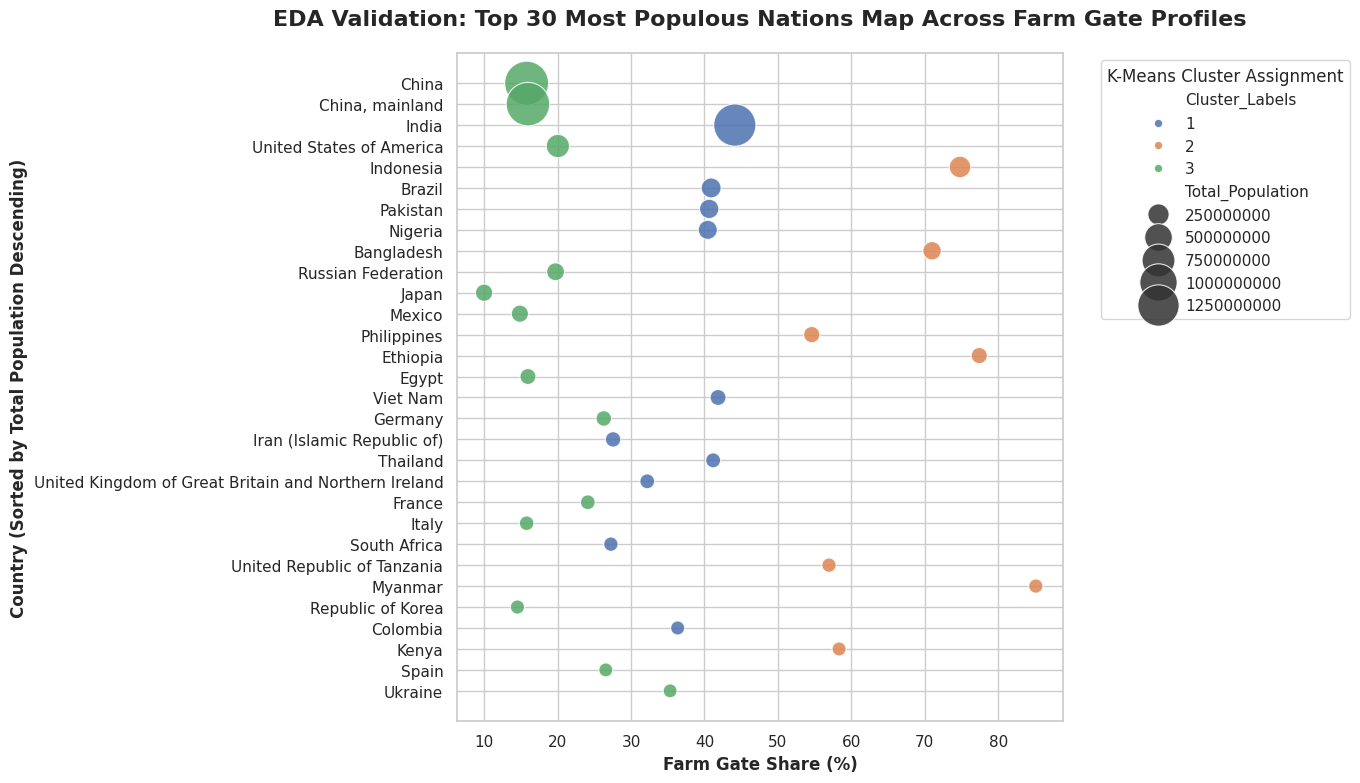

In [172]:

# --- 1. CREATE STRUCTURAL FARM SHARE TIERS FOR GROUPING ---
# We bin the percentages into 4 logical economic tiers
bin_edges = [0, 15, 30, 45, 100]
bin_labels = [
    "Low Farm Share (<15%)",
    "Medium Farm Share (15-30%)",
    "High Farm Share (30-45%)",
    "Extreme Farm Share (>45%)",
]

df_eda = df_collapsed.copy()
df_eda["Farm_Share_Group"] = pd.cut(
    df_eda["Farm_Gate_Share"], bins=bin_edges, labels=bin_labels
)

# --- 2. SORT THE DATA BY POPULATION (DESCENDING) ---
# This ensures our grouping honors the true demographic giants first
df_eda_sorted = df_eda.sort_values(by="Total_Population", ascending=False)

# Let's grab the top 30 most populous countries to keep the chart clean and highly readable
top_populated_countries = df_eda_sorted.head(30)

# --- 3. PLOT THE MULTI-DIMENSIONAL VALIDATION CHART ---
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Create a scatterplot where:
# - X-axis is the Farm Gate Share
# - Y-axis is the Country Name (sorted by population size)
# - Size of the bubble represents total population footprint
# - Color represents the structural cluster your K-Means assigned yesterday!
scatter = sns.scatterplot(
    data=top_populated_countries,
    x="Farm_Gate_Share",
    y="Area",
    size="Total_Population",
    hue="Cluster_Labels",  # Verifying if the binned population giants map cleanly to your clusters
    palette="deep",
    sizes=(100, 1000),  # Scale of the bubbles
    alpha=0.85,
)

# Clean up chart aesthetics for an elite portfolio look
plt.title(
    "EDA Validation: Top 30 Most Populous Nations Map Across Farm Gate Profiles",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Farm Gate Share (%)", fontsize=12, fontweight="bold")
plt.ylabel("Country (Sorted by Total Population Descending)", fontsize=12, fontweight="bold")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="K-Means Cluster Assignment")
plt.tight_layout()

# Display the chart
plt.show()

##App Deployment

In [173]:

# 1. Select only the 'Area' column and the per-capita columns from df_sectors_final
per_capita_cols = [
    'Area',
    'Farm_Gate_Per_Capita',
    'Logistics_Processing_Per_Capita',
    'Consumer_Retail_Per_Capita',
    'Industrial_Per_Capita'
]
df_per_capita_subset = df_sectors_final[per_capita_cols]

# 2. Squash the years by grouping by 'Area' and calculating the decadal mean
df_per_capita_squashed = df_per_capita_subset.groupby('Area', as_index=False).mean()

# 3. Merge the squashed per-capita averages into your master df_collapsed dataset
# This adds the 4 new columns to your existing (165, 12) dataset seamlessly
df_final_production = pd.merge(df_collapsed, df_per_capita_squashed, on='Area', how='left')

# 4. Let's verify the dimensions to ensure everything went perfectly
print("=== Validation Check ===")
print(f"Original df_collapsed shape: {df_collapsed.shape}")
print(f"New production dataset shape: {df_final_production.shape}")
print(f"Number of unique countries: {df_final_production['Area'].nunique()}")


=== Validation Check ===
Original df_collapsed shape: (165, 12)
New production dataset shape: (165, 16)
Number of unique countries: 165


In [174]:
df_final_production.head()

,Area,Total_Population,Farm_Gate_Emissions,Logistics_Processing_Emissions,Consumer_Retail_Emissions,Industrial_Emissions,Total_Food_System_Emissions,Farm_Gate_Share,Logistics_Processing_Share,Consumer_Retail_Share,Industrial_Share,Cluster_Labels,Farm_Gate_Per_Capita,Logistics_Processing_Per_Capita,Consumer_Retail_Per_Capita,Industrial_Per_Capita
0,Albania,2.929244e+06,1689.962670,433.713936,960.496127,1689.110681,4773.283415,35.40,9.09,20.12,35.39,3,0.576965,0.148081,0.327869,0.576653
1,Algeria,3.979736e+07,5427.232727,7437.251800,28771.425291,16962.526318,58598.436136,9.26,12.69,49.10,28.95,1,0.136433,0.186025,0.719102,0.423342
2,Angola,2.794989e+07,5867.547502,1127.006058,3865.073182,2082.293183,12941.919925,45.34,8.71,29.86,16.09,1,0.209074,0.039815,0.138724,0.074280
3,Antigua and Barbuda,9.990891e+04,282.851931,444.572233,86.802182,1826.004417,2640.230763,10.71,16.84,3.29,69.16,0,2.832418,4.454271,0.868540,18.295850
4,Argentina,4.339420e+07,52313.795845,15940.878273,23484.973727,19408.524600,111148.172445,47.07,14.34,21.13,17.46,1,1.205168,0.366739,0.540290,0.447262


In [175]:
# 1. Define all emissions and per-capita columns that we want to clean up
columns_to_round = [
    'Farm_Gate_Emissions',
    'Logistics_Processing_Emissions',
    'Consumer_Retail_Emissions',
    'Industrial_Emissions',
    'Total_Food_System_Emissions',
    'Farm_Gate_Per_Capita',
    'Logistics_Processing_Per_Capita',
    'Consumer_Retail_Per_Capita',
    'Industrial_Per_Capita'
]

# 2. Apply the rounding to 2 decimal places across the dataframe
df_final_production[columns_to_round] = df_final_production[columns_to_round].round(2)

# 3. Print a beautiful preview of our core app display metrics
preview_cols = ['Area', 'Total_Food_System_Emissions', 'Farm_Gate_Per_Capita', 'Cluster_Labels']
print("=== Pristine Production Data Preview ===")
df_final_production[preview_cols].head()

=== Pristine Production Data Preview ===


,Area,Total_Food_System_Emissions,Farm_Gate_Per_Capita,Cluster_Labels
0,Albania,4773.28,0.58,3
1,Algeria,58598.44,0.14,1
2,Angola,12941.92,0.21,1
3,Antigua and Barbuda,2640.23,2.83,0
4,Argentina,111148.17,1.21,1


In [176]:
# 1. Define the four core per-capita columns
per_capita_sectors = [
    'Farm_Gate_Per_Capita',
    'Logistics_Processing_Per_Capita',
    'Consumer_Retail_Per_Capita',
    'Industrial_Per_Capita'
]

# 2. Sum them horizontally to create the Total Per Capita column
df_final_production['Total_Food_System_Per_Capita'] = df_final_production[per_capita_sectors].sum(axis=1).round(2)

# 3. Print a beautiful confirmation to verify it works
print("=== Master Data Validation ===")
print(f"Final Data Shape: {df_final_production.shape}")
print("\nConfirming your columns are perfectly aligned:")
for col in df_final_production.columns:
    print(f"• {col}")

=== Master Data Validation ===
Final Data Shape: (165, 17)

Confirming your columns are perfectly aligned:
• Area
• Total_Population
• Farm_Gate_Emissions
• Logistics_Processing_Emissions
• Consumer_Retail_Emissions
• Industrial_Emissions
• Total_Food_System_Emissions
• Farm_Gate_Share
• Logistics_Processing_Share
• Consumer_Retail_Share
• Industrial_Share
• Cluster_Labels
• Farm_Gate_Per_Capita
• Logistics_Processing_Per_Capita
• Consumer_Retail_Per_Capita
• Industrial_Per_Capita
• Total_Food_System_Per_Capita


In [177]:


# 1. Save your pristine master dataset as a CSV
df_final_production.to_csv("final_food_system_clusters.csv", index=False)

# 2. Save your actual pre-trained K-Means model using the correct variable name
joblib.dump(kmeans_final, "trained_kmeans_model.joblib")

print("🎉 Success! 'final_food_system_clusters.csv' and 'trained_kmeans_model.joblib' are officially exported and ready for download.")

🎉 Success! 'final_food_system_clusters.csv' and 'trained_kmeans_model.joblib' are officially exported and ready for download.
